In [1]:
import os
import torch
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean

from src.training.stars import StarTraining

# settings
n_clusters = 4
trimmed = False

# results folder
results_folder = os.path.join("results", "tree", "multi_ellipsoidal_star", "{}_clusters".format(n_clusters) + ("_trimmed" if trimmed else ""))
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(31)

Data shape: torch.Size([2000, 3])


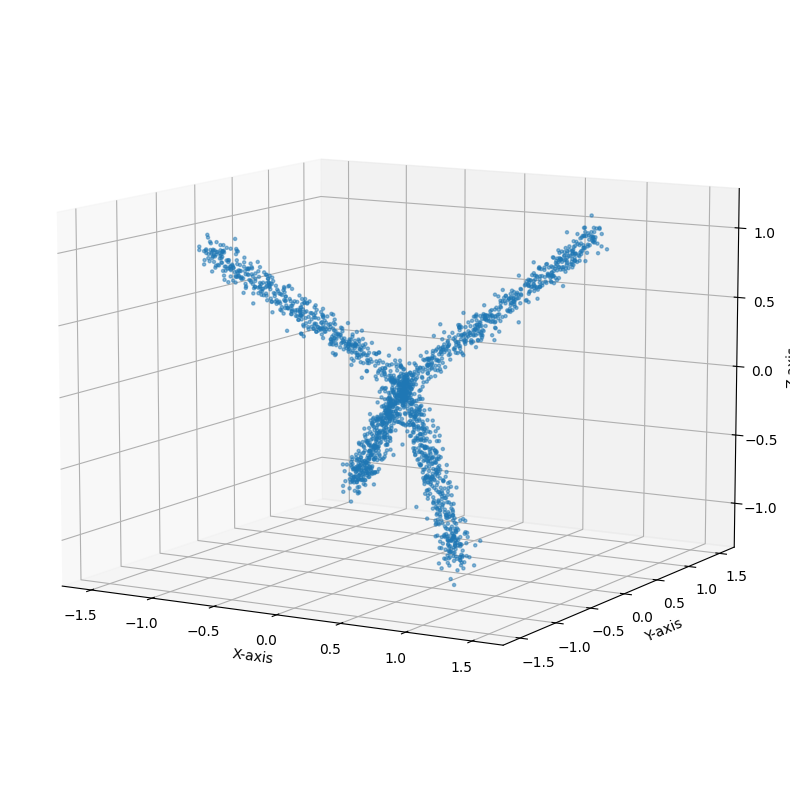

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

## Learn Star ##

In [3]:
trainer = StarTraining([3], n_clusters, covariance_type='full', trimmed=trimmed)

In [4]:
trainer.fit(data)
star = trainer.star
psi = StarVectorDiffeomorphism(3, star, s=1.)

In [5]:
# generate samples from the distribution
num_samples = 1000
samples = star.sample(num_samples)

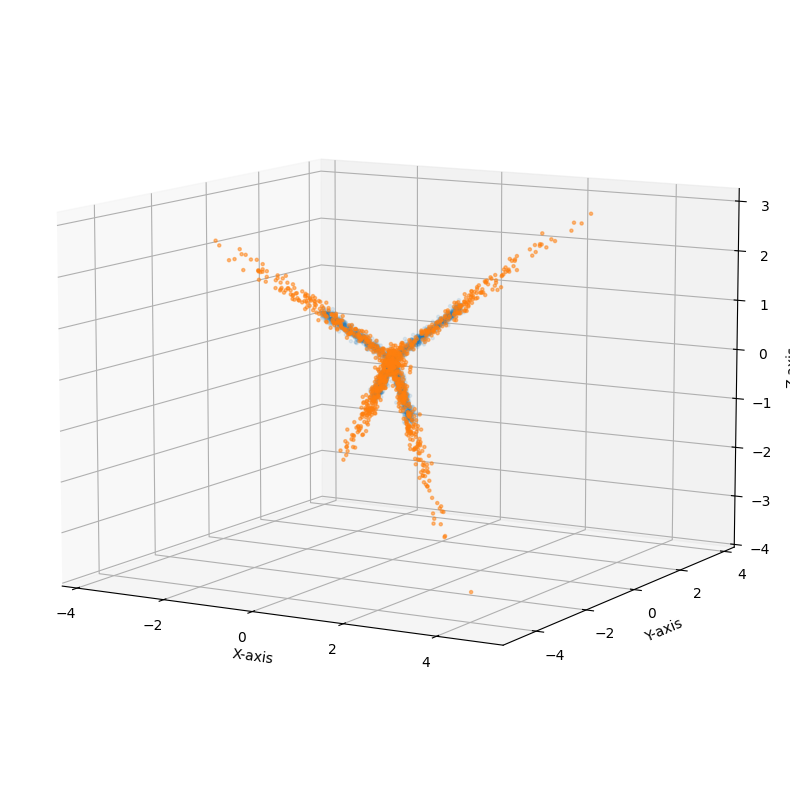

In [6]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1)
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5,)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data+samples.png"))
plt.show()

In [7]:
manifold = StandardPullbackVectorEuclidean(psi)
iso_manifold = l2IsometrizedVectorEuclidean(manifold, num_intervals=20)

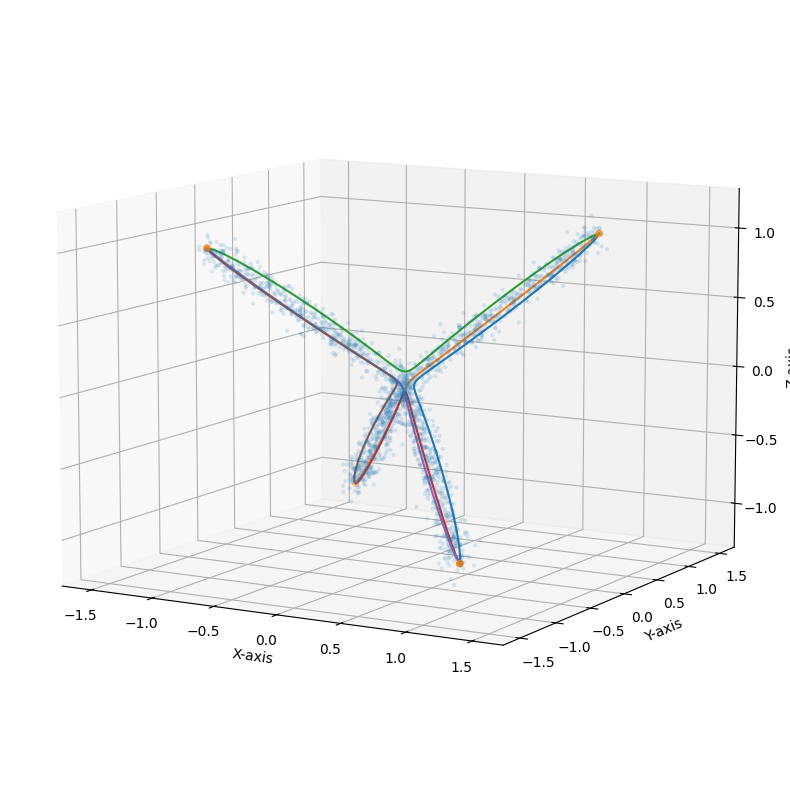

In [8]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    geodesics = manifold.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(geodesics[i, j, :, 0].numpy(), geodesics[i, j, :, 1].numpy(), geodesics[i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

## Construct Visualizations ##

In [9]:
# restrict data to high likelihood region
with torch.no_grad():
    diffeo_data = psi(data)
    # keep points with norm less than 0.5
    likehlihood_labels = (diffeo_data.norm(dim=-1) <= 1.)
    all_points = data[likehlihood_labels == 1]
    print("Number of points in high likelihood region:", all_points.shape[0])

Number of points in high likelihood region: 1014


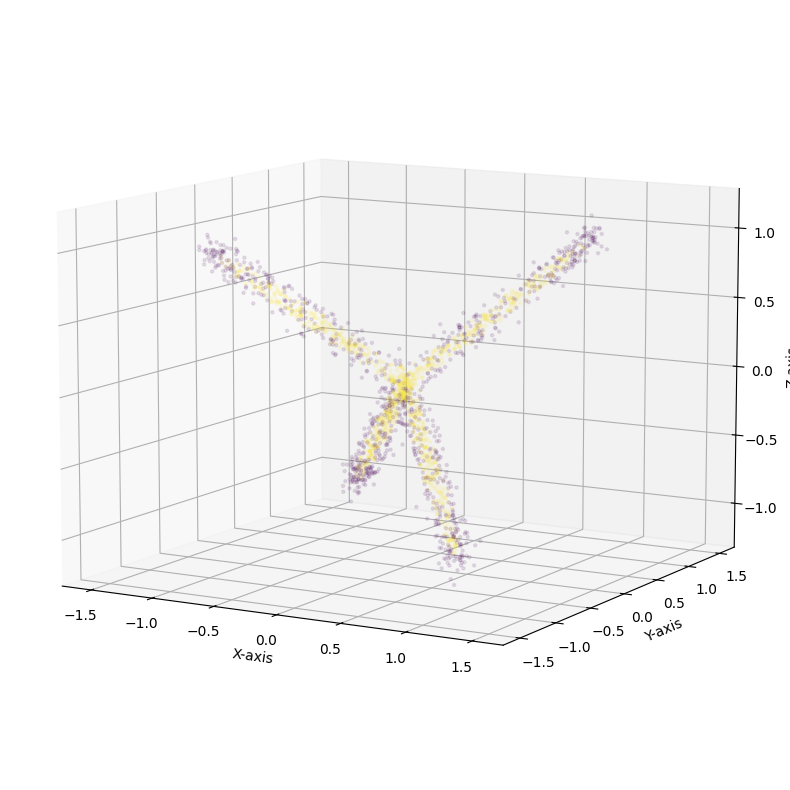

In [10]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), c=likehlihood_labels, s=5, alpha=0.1, label='Original Data')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

In [11]:
pairwise_distances = torch.norm(all_points[:, None] - all_points[None], dim=-1)
with torch.no_grad():
    iso_pairwise_distances = iso_manifold.distance(all_points[None], all_points[None])[0]
    # symmetricize iso_pairwise_distances
    iso_pairwise_distances = (iso_pairwise_distances + iso_pairwise_distances.transpose(0, 1)) / 2

### MDS ###

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


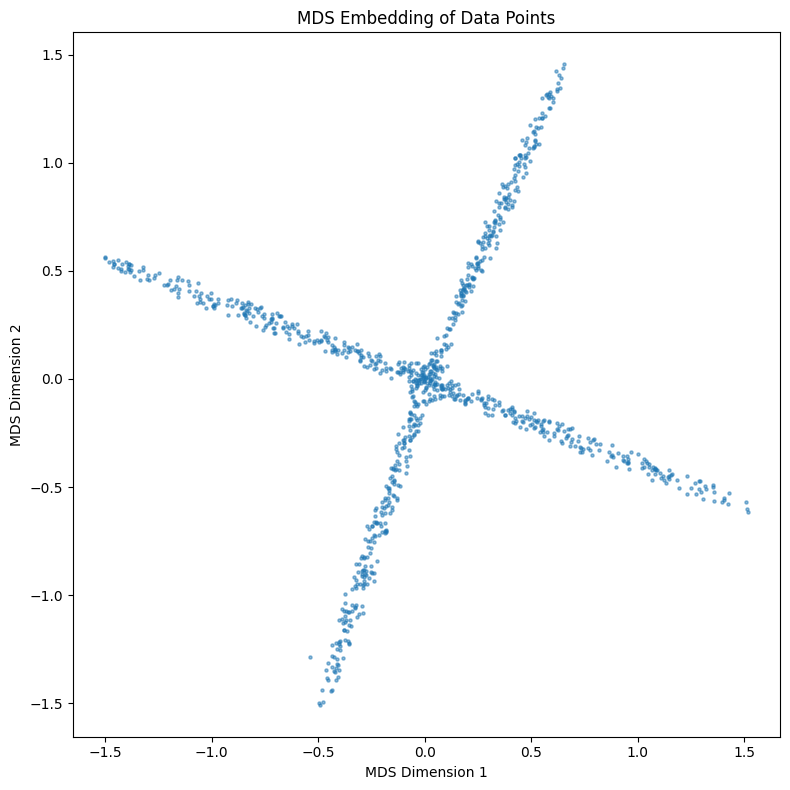

In [12]:
from sklearn.manifold import MDS
# MDS embedding
mds = MDS(n_components=2, dissimilarity='precomputed')
mds_embedding = mds.fit_transform(pairwise_distances.numpy())      

plt.figure(figsize=(8, 8))
plt.scatter(mds_embedding[:, 0], mds_embedding[:, 1], s=5, alpha=0.5)
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.title("MDS Embedding of Data Points")
plt.tight_layout()
plt.show()